In [5]:
import numpy as np
from stl import mesh
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

In [2]:
''' set paths '''
data_folder = f"../data/brain_surface/"
save_figs = f"../figures/hpc_projection_cells/"
brain_file = 'chickadee_brain.npy'

In [3]:
# load brain dict
d = np.load(f'{data_folder}{brain_file}', allow_pickle=True)
data = d.item()
print(data.keys())

dict_keys(['brain', 'hpc', 'mm', 'surface'])


In [4]:
''' create a mesh from the surface vertices and faces '''
# data params
vertices = data['surface']['vertices'].copy()
faces = data['surface']['faces'].copy()
n_faces = faces.shape[0]

# make the mesh
mesh_brain = mesh.Mesh(np.zeros(n_faces, dtype=mesh.Mesh.dtype))
for i, f in enumerate(faces):
    for j in range(3):
        mesh_brain.vectors[i, j] = vertices[f[j], :]

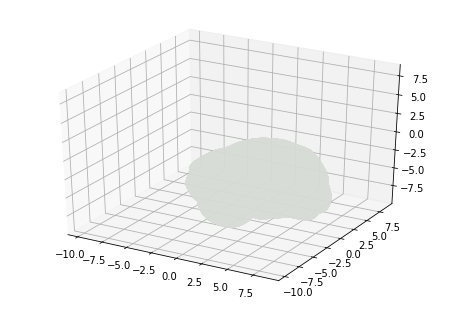

In [14]:
''' try plotting it '''
# fig params
fig = plt.figure()
ax = mplot3d.Axes3D(fig)

# plot the mesh
brain_poly = mplot3d.art3d.Poly3DCollection(mesh_brain.vectors)
brain_poly.set_alpha(0.3)
brain_poly.set_facecolor('xkcd:light gray')
brain_poly.set_edgecolor('xkcd:light gray')
ax.add_collection3d(brain_poly)

# scale to the mesh size
scale = mesh_brain.points.flatten()
ax.auto_scale_xyz(scale, scale, scale)

plt.show()
fig.savefig(f'{save_figs}brain_3d.png', dpi=600, bbox_inches='tight')

In [ ]:
'''
TODO:
- make this look better: shading/light, Alex's 3D plot tools (remove the axes etc..)
- get the HPC mesh from the HPC points...use the mesh function after first thresholding at 0.4
https://github.com/WoLpH/numpy-stl
'''

In [14]:
mesh_brain.vectors.shape

(121492, 3, 3)

In [15]:
i

121475

In [17]:
f[j]

60748

In [18]:
vertices.shape

(60748, 3)

In [20]:
faces.shape[0] / vertices.shape[0]

1.9999341542108382

In [21]:
faces[60748]

array([30635, 30636, 30637], dtype=uint16)

In [22]:
faces[0]

array([1, 2, 3], dtype=uint16)